In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from scipy.optimize import curve_fit

# Load the CSV file
df = pd.read_csv("Nat_Gas.csv")

# Convert dates using 'mixed' format to safely handle any year-length differences
df['Dates'] = pd.to_datetime(df['Dates'], format='mixed')
df = df.sort_values('Dates')

# Calculate days since the start of the dataset
min_date = df['Dates'].min()
df['Days'] = (df['Dates'] - min_date).dt.days

# Preview the first few rows to confirm it worked
df.head()

,Dates,Prices,Days
0,2020-10-31,10.1,0
1,2020-11-30,10.3,30
2,2020-12-31,11.0,61
3,2021-01-31,10.9,92
4,2021-02-28,10.9,120


In [7]:
def price_model(t, amplitude, frequency, phase_shift, slope, intercept):
    return amplitude * np.sin(frequency * t + phase_shift) + slope * t + intercept

# Initial guesses for the curve_fit algorithm
initial_guesses = [0.5, 2 * np.pi / 365.25, 0, 0.001, 10]

# Fit the model
popt, pcov = curve_fit(price_model, df['Days'], df['Prices'], p0=initial_guesses)
print("Optimal parameters found:", popt)

Optimal parameters found: [ 6.91815081e-01  1.73011410e-02 -1.08103154e-01  1.49915280e-03
  1.01339482e+01]


In [8]:
def estimate_price(input_date_str):
    target_date = pd.to_datetime(input_date_str)
    days_since = (target_date - min_date).days
    estimated_price = price_model(days_since, *popt)
    return estimated_price

print(f"Estimated Price for Jan 15, 2022: ${estimate_price('2022-01-15'):.2f}")
print(f"Estimated Price for July 4, 2025: ${estimate_price('2025-07-04'):.2f}")

Estimated Price for Jan 15, 2022: $11.45
Estimated Price for July 4, 2025: $12.06


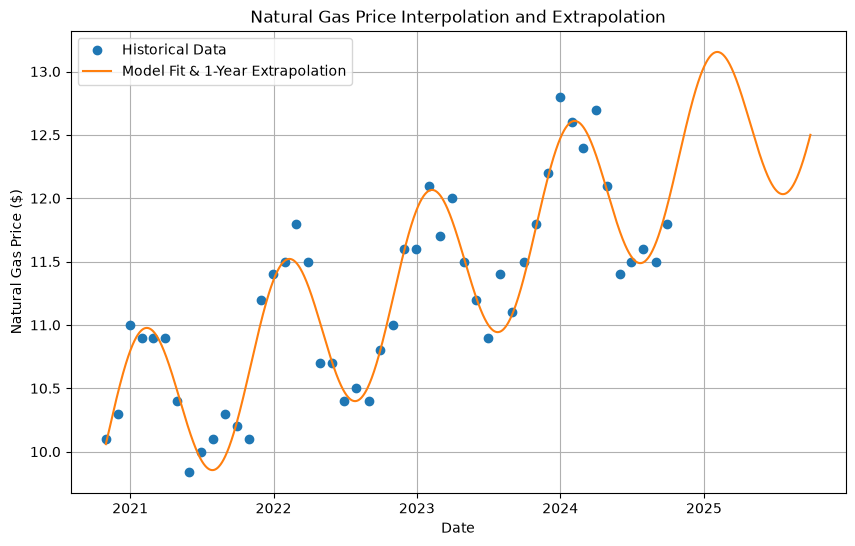

In [9]:
# Create future dates for extrapolation
future_days = np.arange(0, df['Days'].max() + 365, 1)
future_dates = [min_date + timedelta(days=int(d)) for d in future_days]
predicted_prices = price_model(future_days, *popt)

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(df['Dates'], df['Prices'], 'o', label='Historical Data')
plt.plot(future_dates, predicted_prices, '-', label='Model Fit & 1-Year Extrapolation')
plt.xlabel('Date')
plt.ylabel('Natural Gas Price ($)')
plt.title('Natural Gas Price Interpolation and Extrapolation')
plt.legend()
plt.grid(True)
plt.show()